## Notebook 06 — Out-of-Sample Backtest

This notebook constructs and evaluates a signal-based long/short strategy using the commodity momentum spillover signals identified in notebooks 04 and 05.

**Strategy logic:**

$$\text{Position}_{Y,t} = \text{sign}\left(M_{X,\, t-k^*}^{(w^*)}\right)$$

Go long the equity ETF when the lagged commodity momentum signal is positive, short when negative. Hold for one day.

**Train/test split:**
- **In-sample (train):** 2010-01-01 — 2019-12-31
- **Out-of-sample (test):** 2020-01-01 — 2026-05-22

The optimal lag $k^*$ and window $w^*$ are selected on the training set only (from notebook 04 Granger results), then applied unchanged to the test set. This is a strict out-of-sample evaluation.

**Sections:**
1. Load data and define strategy parameters
2. Signal construction
3. Backtest engine
4. Performance metrics
5. Equity curves
6. Regime analysis
7. Benchmark comparison
8. Save results

---
### 1. Load Data & Parameters

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import os
import warnings
warnings.filterwarnings('ignore')

PROC_DIR = os.path.join("..", "data", "processed")
OUT_DIR  = os.path.join("..", "outputs")
FIG_DIR  = os.path.join("..", "figures")
os.makedirs(OUT_DIR, exist_ok=True)

PAIRS = [
    ("WTI",    "XLE"),
    ("Brent",  "XLE"),
    ("Copper", "XLB"),
    ("Gold",   "GDX"),
    ("NatGas", "XLE"),
]

COLORS = {
    "WTI"   : "#e07b39",
    "Brent" : "#e0a039",
    "Copper": "#b5651d",
    "NatGas": "#6b8e23",
    "Gold"  : "#c5a028",
    "XLE"   : "#4a9eda",
    "XLB"   : "#6dbf6d",
    "GDX"   : "#c47fd4",
}

TRAIN_END  = pd.Timestamp("2019-12-31")
TEST_START = pd.Timestamp("2020-01-01")
BREAK_COVID  = pd.Timestamp("2020-03-01")
BREAK_ENERGY = pd.Timestamp("2022-02-01")

# Load optimal lags (determined on full sample Granger — used as fixed params)
optimal_df = pd.read_csv(os.path.join(OUT_DIR, "optimal_lags.csv"))
optimal_lags = {}
for _, row in optimal_df.iterrows():
    optimal_lags[(row["Commodity"], row["Equity"])] = {
        "lag": int(row["Optimal_Lag"]),
        "window": int(row["Optimal_Window"])
    }

# Load momentum signals and returns
momentum = {}
for w in [5, 10, 20]:
    momentum[w] = pd.read_csv(
        os.path.join(PROC_DIR, f"momentum_w{w}.csv"),
        index_col=0, parse_dates=True
    )

returns = pd.read_csv(
    os.path.join(PROC_DIR, "log_returns.csv"),
    index_col=0, parse_dates=True
)

print("Parameters:")
print(f"  Train : {returns.index[0].date()} → {TRAIN_END.date()}")
print(f"  Test  : {TEST_START.date()} → {returns.index[-1].date()}")
print(f"  Train days : {(returns.index <= TRAIN_END).sum()}")
print(f"  Test days  : {(returns.index >= TEST_START).sum()}")
print("\nStrategy parameters:")
for (c, e), params in optimal_lags.items():
    print(f"  {c}→{e} : lag={params['lag']}, window={params['window']}")

Parameters:
  Train : 2010-01-05 → 2019-12-31
  Test  : 2020-01-01 → 2026-05-22
  Train days : 2515
  Test days  : 1607

Strategy parameters:
  WTI→XLE : lag=4, window=20
  Brent→XLE : lag=4, window=20
  Copper→XLB : lag=5, window=20
  Gold→GDX : lag=3, window=5
  NatGas→XLE : lag=4, window=20


---
### 2. Signal Construction

For each pair, construct the position signal:
$$\text{Position}_{Y,t} = \text{sign}\left(M_{X,\, t-k^*}^{(w^*)}\right)$$

In [3]:
signals = {}

for comm, eq in PAIRS:
    params = optimal_lags[(comm, eq)]
    lag    = params["lag"]
    w      = params["window"]

    # Signal: sign of lagged commodity momentum
    raw_signal = momentum[w][comm].shift(lag)
    position   = np.sign(raw_signal)

    # Daily strategy return
    strat_return = position * returns[eq]

    signals[(comm, eq)] = {
        "position"    : position,
        "strat_return": strat_return,
        "eq_return"   : returns[eq],
        "lag"         : lag,
        "window"      : w
    }

print("Signals constructed for all pairs.")
for (c, e), s in signals.items():
    pos_pct = (s["position"] > 0).mean()
    print(f"  {c}→{e} : long {pos_pct:.1%} of days | short {1-pos_pct:.1%} of days")

Signals constructed for all pairs.
  WTI→XLE : long 53.1% of days | short 46.9% of days
  Brent→XLE : long 54.7% of days | short 45.3% of days
  Copper→XLB : long 53.7% of days | short 46.3% of days
  Gold→GDX : long 55.1% of days | short 44.9% of days
  NatGas→XLE : long 48.8% of days | short 51.2% of days


---
### 3. Backtest Engine

In [4]:
def compute_metrics(returns_series, label=""):
    """
    Compute annualised performance metrics for a daily return series.
    """
    r = returns_series.dropna()
    if len(r) == 0:
        return {}

    ann_return = r.mean() * 252
    ann_vol    = r.std()  * np.sqrt(252)
    sharpe     = ann_return / ann_vol if ann_vol > 0 else np.nan

    cumret  = (1 + r).cumprod()
    running_max = cumret.cummax()
    drawdown    = (cumret - running_max) / running_max
    max_dd      = drawdown.min()

    hit_rate    = (r > 0).mean()
    total_ret   = cumret.iloc[-1] - 1
    calmar      = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        "Label"      : label,
        "Ann_Return" : round(ann_return, 4),
        "Ann_Vol"    : round(ann_vol,    4),
        "Sharpe"     : round(sharpe,     4),
        "Max_DD"     : round(max_dd,     4),
        "Calmar"     : round(calmar,     4),
        "Hit_Rate"   : round(hit_rate,   4),
        "Total_Ret"  : round(total_ret,  4),
        "N_Days"     : len(r)
    }


# Run backtest for all pairs across train and test periods
all_metrics = []

for comm, eq in PAIRS:
    s = signals[(comm, eq)]
    sr = s["strat_return"]
    er = s["eq_return"]

    # Split
    sr_train = sr[sr.index <= TRAIN_END]
    sr_test  = sr[sr.index >= TEST_START]
    er_train = er[er.index <= TRAIN_END]
    er_test  = er[er.index >= TEST_START]

    for period, strat, bench in [
        ("Train", sr_train, er_train),
        ("Test",  sr_test,  er_test),
        ("Full",  sr,       er),
    ]:
        m_strat = compute_metrics(strat, label=f"{comm}→{eq} Strategy")
        m_bench = compute_metrics(bench, label=f"{eq} Buy & Hold")
        m_strat["Pair"]   = f"{comm}→{eq}"
        m_strat["Period"] = period
        m_strat["Type"]   = "Strategy"
        m_bench["Pair"]   = f"{comm}→{eq}"
        m_bench["Period"] = period
        m_bench["Type"]   = "Benchmark"
        all_metrics.extend([m_strat, m_bench])

metrics_df = pd.DataFrame(all_metrics)

---
### 4. Performance Metrics Table

In [5]:
# Out-of-sample results — the key table
oos = metrics_df[metrics_df["Period"] == "Test"].copy()

print("OUT-OF-SAMPLE PERFORMANCE (2020–2026)")
print("=" * 90)
print(f"{'Pair':<15} {'Type':<12} {'Ann Ret':>9} {'Ann Vol':>9} {'Sharpe':>8} {'Max DD':>9} {'Hit Rate':>10} {'Total Ret':>10}")
print("-" * 90)

for (pair, ptype), group in oos.groupby(["Pair", "Type"], sort=False):
    row = group.iloc[0]
    print(f"{pair:<15} {ptype:<12} {row['Ann_Return']:>9.2%} {row['Ann_Vol']:>9.2%} "
          f"{row['Sharpe']:>8.3f} {row['Max_DD']:>9.2%} {row['Hit_Rate']:>10.2%} {row['Total_Ret']:>10.2%}")

print("\nIN-SAMPLE PERFORMANCE (2010–2019)")
print("=" * 90)
print(f"{'Pair':<15} {'Type':<12} {'Ann Ret':>9} {'Ann Vol':>9} {'Sharpe':>8} {'Max DD':>9} {'Hit Rate':>10} {'Total Ret':>10}")
print("-" * 90)

ins = metrics_df[metrics_df["Period"] == "Train"].copy()
for (pair, ptype), group in ins.groupby(["Pair", "Type"], sort=False):
    row = group.iloc[0]
    print(f"{pair:<15} {ptype:<12} {row['Ann_Return']:>9.2%} {row['Ann_Vol']:>9.2%} "
          f"{row['Sharpe']:>8.3f} {row['Max_DD']:>9.2%} {row['Hit_Rate']:>10.2%} {row['Total_Ret']:>10.2%}")

OUT-OF-SAMPLE PERFORMANCE (2020–2026)
Pair            Type           Ann Ret   Ann Vol   Sharpe    Max DD   Hit Rate  Total Ret
------------------------------------------------------------------------------------------
WTI→XLE         Strategy         4.97%    34.40%    0.145   -61.71%     50.90%     -5.52%
WTI→XLE         Benchmark       15.58%    34.39%    0.453   -63.71%     53.64%     84.00%
Brent→XLE       Strategy        10.16%    34.39%    0.295   -60.11%     50.90%     31.53%
Brent→XLE       Benchmark       15.58%    34.39%    0.453   -63.71%     53.64%     84.00%
Copper→XLB      Strategy        -2.74%    23.12%   -0.118   -57.25%     50.53%    -29.25%
Copper→XLB      Benchmark       10.49%    23.11%    0.454   -39.05%     52.15%     64.50%
Gold→GDX        Strategy       -21.16%    40.86%   -0.518   -85.96%     48.35%    -84.79%
Gold→GDX        Benchmark       17.56%    40.87%    0.430   -55.67%     50.34%     78.47%
NatGas→XLE      Strategy        -5.26%    34.40%   -0.153   -

---
### 5. Equity Curves

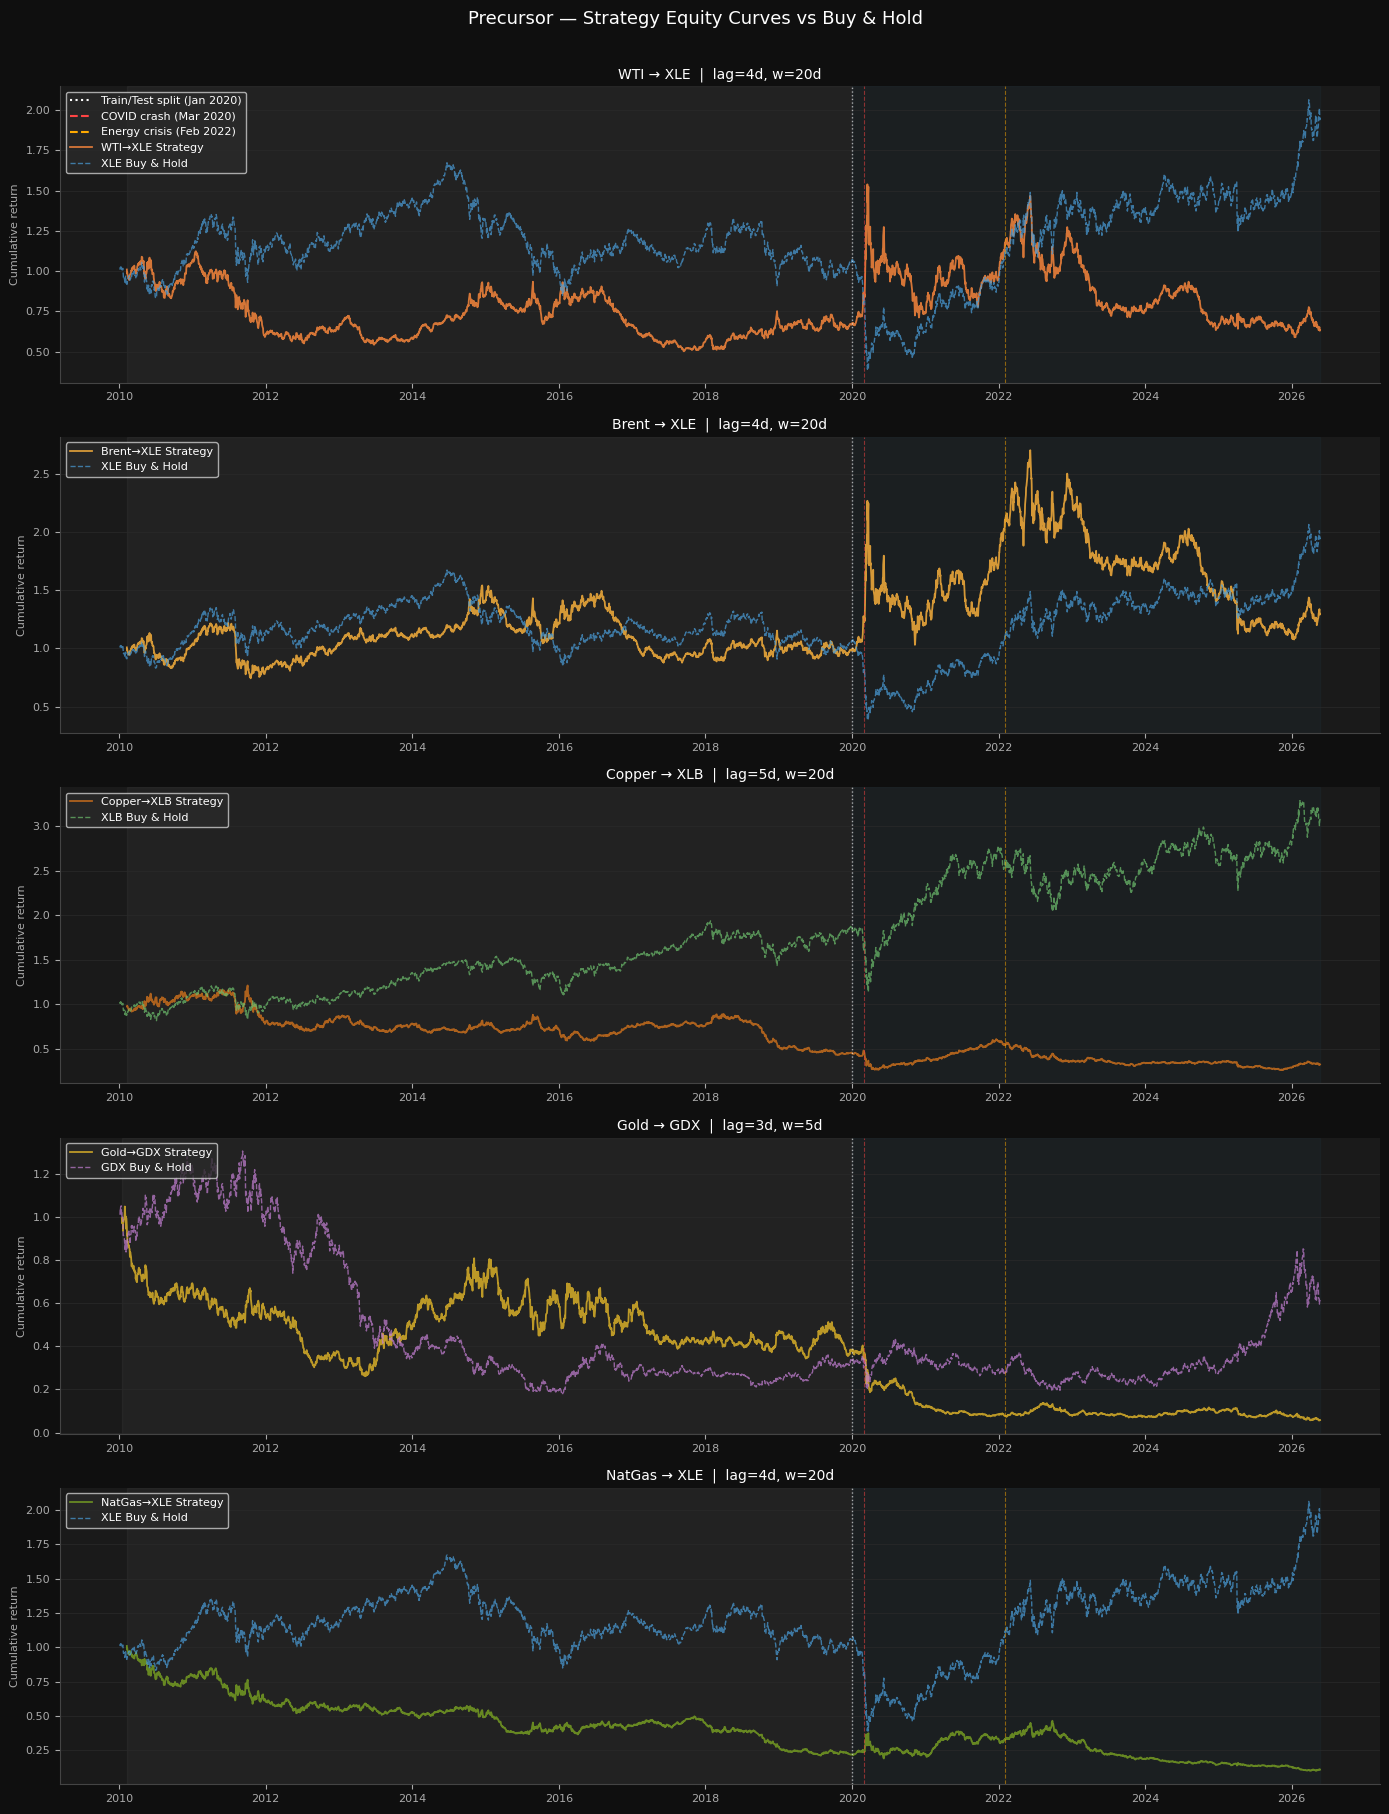

Saved: figures/06_equity_curves.png


In [6]:
fig, axes = plt.subplots(len(PAIRS), 1, figsize=(14, 18), facecolor="#0f0f0f", sharex=False)

for i, (comm, eq) in enumerate(PAIRS):
    ax = axes[i]
    ax.set_facecolor("#1a1a1a")

    s  = signals[(comm, eq)]
    sr = s["strat_return"].dropna()
    er = s["eq_return"].dropna()

    strat_curve = (1 + sr).cumprod()
    bench_curve = (1 + er).cumprod()

    ax.plot(strat_curve.index, strat_curve, color=COLORS[comm], linewidth=1.3,
            label=f"{comm}→{eq} Strategy", alpha=0.95)
    ax.plot(bench_curve.index, bench_curve, color=COLORS[eq],   linewidth=1.0,
            label=f"{eq} Buy & Hold", alpha=0.7, linestyle="--")

    # Train/test split line
    ax.axvline(TEST_START, color="#ffffff", linewidth=1.0, linestyle=":", alpha=0.6)
    ax.axvline(BREAK_COVID,  color="#ff4444", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.axvline(BREAK_ENERGY, color="#ffaa00", linewidth=0.8, linestyle="--", alpha=0.5)

    # Shade train/test regions
    ax.axvspan(sr.index[0], TRAIN_END, alpha=0.04, color="white")
    ax.axvspan(TEST_START,  sr.index[-1], alpha=0.04, color="#4a9eda")

    ax.set_title(f"{comm} → {eq}  |  lag={s['lag']}d, w={s['window']}d",
                 color="white", fontsize=10, pad=6)
    ax.legend(facecolor="#2a2a2a", labelcolor="white", fontsize=8, loc="upper left")
    ax.tick_params(colors="#aaaaaa", labelsize=8)
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["bottom","left"]].set_color("#444444")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(axis="y", color="#2a2a2a", linewidth=0.5)
    ax.set_ylabel("Cumulative return", color="#aaaaaa", fontsize=8)

# Global legend for vertical lines
legend_lines = [
    plt.Line2D([0],[0], color="white",   linestyle=":",  label="Train/Test split (Jan 2020)"),
    plt.Line2D([0],[0], color="#ff4444", linestyle="--", label="COVID crash (Mar 2020)"),
    plt.Line2D([0],[0], color="#ffaa00", linestyle="--", label="Energy crisis (Feb 2022)"),
]
axes[0].legend(handles=legend_lines + axes[0].get_legend_handles_labels()[0],
               facecolor="#2a2a2a", labelcolor="white", fontsize=8, loc="upper left")

fig.suptitle("Precursor — Strategy Equity Curves vs Buy & Hold",
             color="white", fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "06_equity_curves.png"), dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("Saved: figures/06_equity_curves.png")

---
### 6. Drawdown Curves

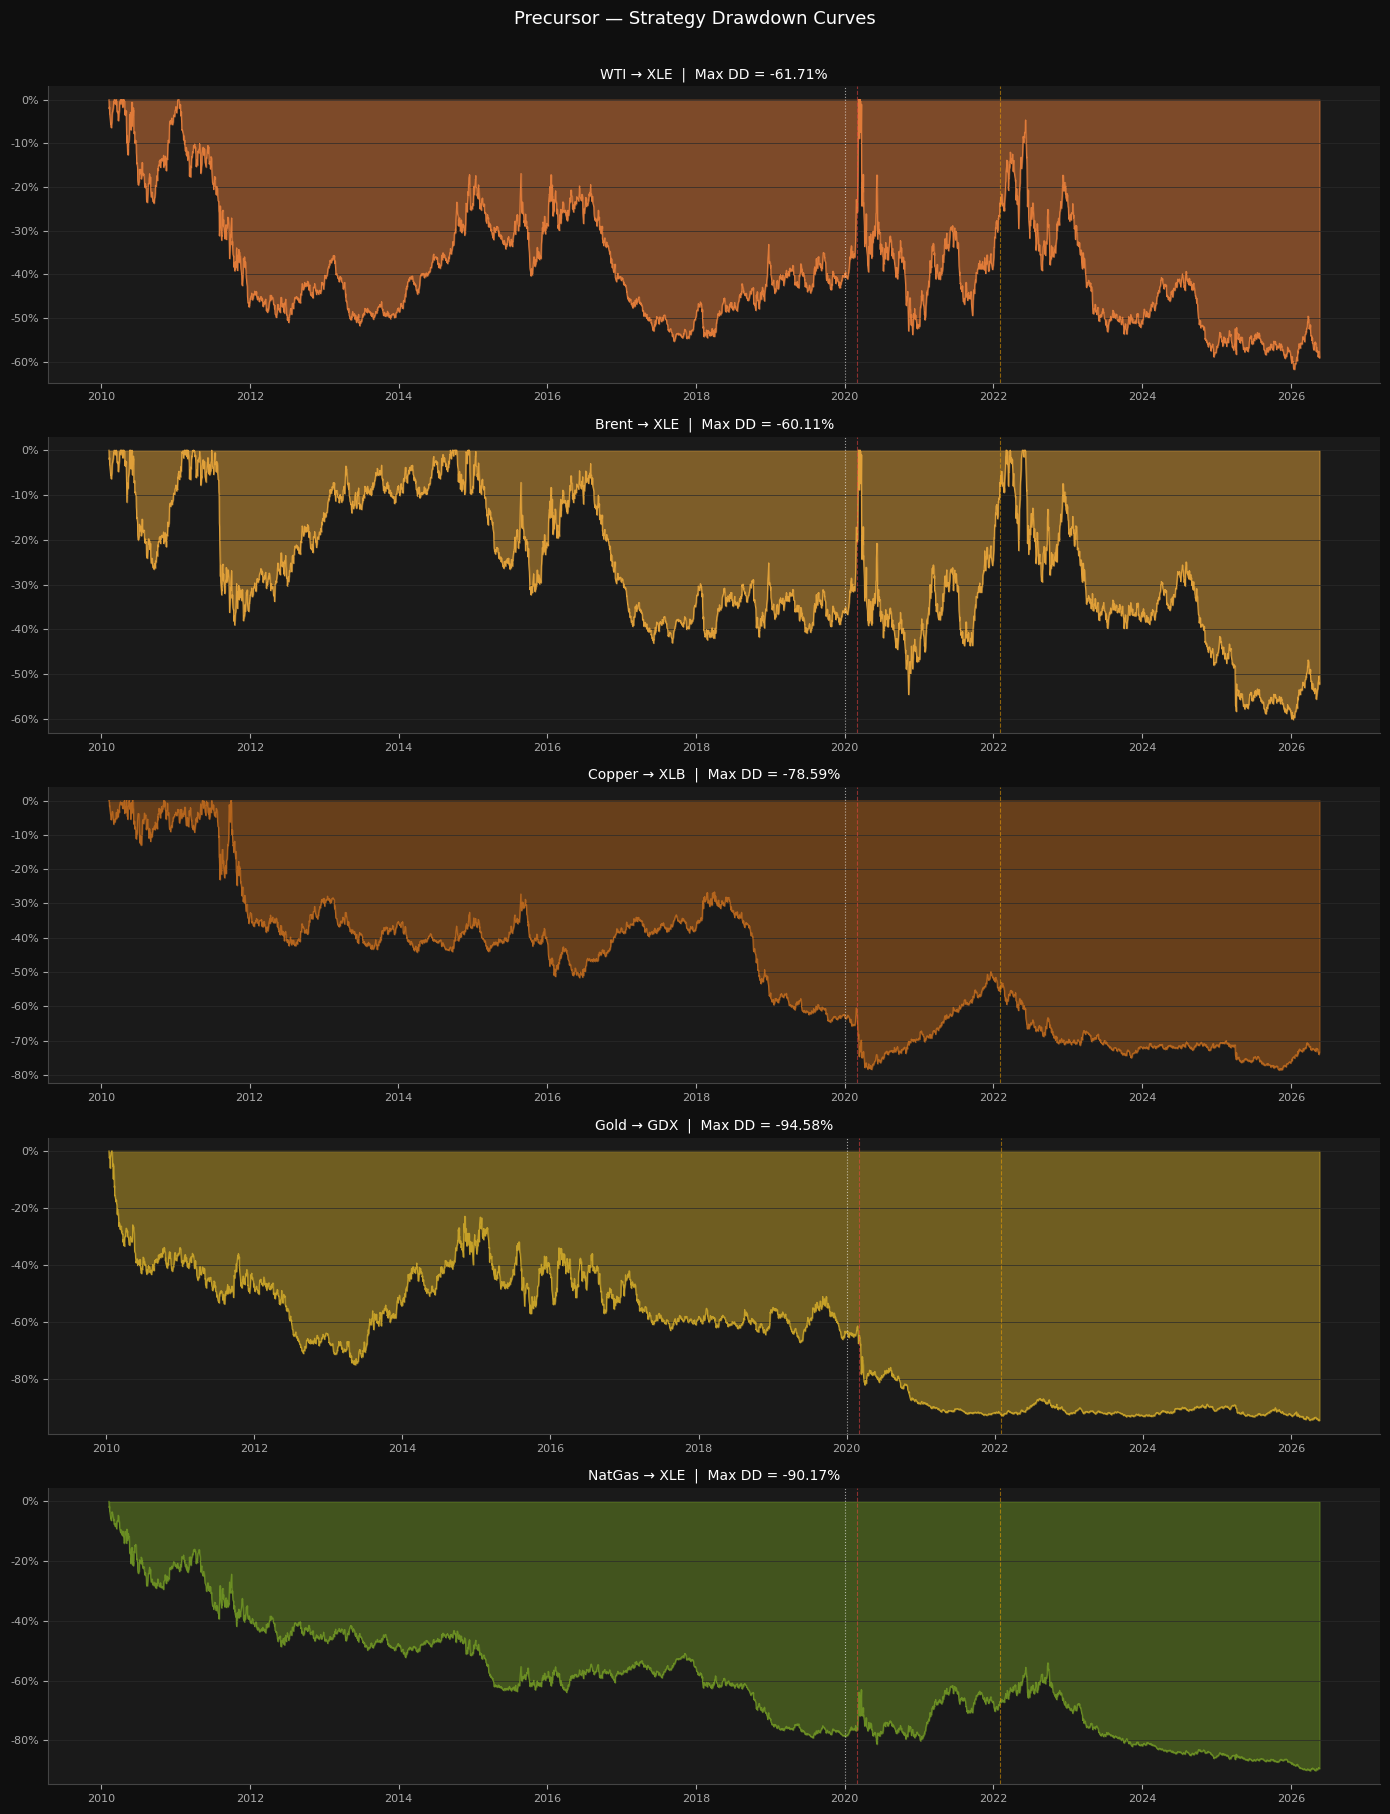

Saved: figures/06_drawdowns.png


In [7]:
fig, axes = plt.subplots(len(PAIRS), 1, figsize=(14, 18), facecolor="#0f0f0f", sharex=False)

for i, (comm, eq) in enumerate(PAIRS):
    ax = axes[i]
    ax.set_facecolor("#1a1a1a")

    sr = signals[(comm, eq)]["strat_return"].dropna()
    cumret      = (1 + sr).cumprod()
    running_max = cumret.cummax()
    drawdown    = (cumret - running_max) / running_max

    ax.fill_between(drawdown.index, drawdown, 0, color=COLORS[comm], alpha=0.5)
    ax.plot(drawdown.index, drawdown, color=COLORS[comm], linewidth=0.8)
    ax.axvline(TEST_START,   color="white",   linewidth=0.8, linestyle=":", alpha=0.6)
    ax.axvline(BREAK_COVID,  color="#ff4444", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.axvline(BREAK_ENERGY, color="#ffaa00", linewidth=0.8, linestyle="--", alpha=0.5)

    ax.set_title(f"{comm} → {eq}  |  Max DD = {drawdown.min():.2%}",
                 color="white", fontsize=10, pad=6)
    ax.tick_params(colors="#aaaaaa", labelsize=8)
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["bottom","left"]].set_color("#444444")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.grid(axis="y", color="#2a2a2a", linewidth=0.5)

fig.suptitle("Precursor — Strategy Drawdown Curves",
             color="white", fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "06_drawdowns.png"), dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("Saved: figures/06_drawdowns.png")

---
### 7. Regime Performance

How does the strategy perform across the three market regimes identified in notebook 05b?

In [8]:
regimes = {
    "Pre-COVID (2010–2020)" : (pd.Timestamp("2010-01-01"), BREAK_COVID),
    "COVID (2020–2022)"     : (BREAK_COVID, BREAK_ENERGY),
    "Post-Energy (2022–)"   : (BREAK_ENERGY, pd.Timestamp("2026-12-31")),
}

print("REGIME PERFORMANCE — Sharpe Ratio per Pair per Regime")
print("=" * 70)
header = f"{'Pair':<15}" + "".join(f"{r:>22}" for r in regimes)
print(header)
print("-" * 70)

regime_records = []

for comm, eq in PAIRS:
    sr   = signals[(comm, eq)]["strat_return"].dropna()
    row  = f"{comm}→{eq:<10}"
    for regime_name, (start, end) in regimes.items():
        chunk   = sr[(sr.index >= start) & (sr.index < end)]
        metrics = compute_metrics(chunk)
        sharpe  = metrics.get("Sharpe", np.nan)
        row    += f"{sharpe:>22.3f}"
        regime_records.append({
            "Pair"  : f"{comm}→{eq}",
            "Regime": regime_name,
            "Sharpe": sharpe,
            "Ann_Return": metrics.get("Ann_Return", np.nan),
            "Max_DD"    : metrics.get("Max_DD", np.nan),
        })
    print(row)

regime_df = pd.DataFrame(regime_records)

REGIME PERFORMANCE — Sharpe Ratio per Pair per Regime
Pair            Pre-COVID (2010–2020)     COVID (2020–2022)   Post-Energy (2022–)
----------------------------------------------------------------------
WTI→XLE                        0.043                 0.526                -0.394
Brent→XLE                        0.221                 0.735                -0.271
Copper→XLB                       -0.288                 0.404                -0.551
Gold→GDX                       -0.112                -1.374                 0.010
NatGas→XLE                       -0.532                 0.519                -0.857


---
### 8. Save Results

In [9]:
metrics_df.to_csv(os.path.join(OUT_DIR, "backtest_metrics.csv"), index=False)
print(f"Saved: outputs/backtest_metrics.csv")

regime_df.to_csv(os.path.join(OUT_DIR, "backtest_regime.csv"), index=False)
print(f"Saved: outputs/backtest_regime.csv")

# Save daily strategy returns for each pair
for comm, eq in PAIRS:
    sr = signals[(comm, eq)]["strat_return"]
    sr.to_csv(os.path.join(OUT_DIR, f"strat_returns_{comm.lower()}_{eq.lower()}.csv"))
print(f"Saved: individual strategy return series")

print(f"\nAll outputs saved to: {os.path.abspath(OUT_DIR)}")

Saved: outputs/backtest_metrics.csv
Saved: outputs/backtest_regime.csv
Saved: individual strategy return series

All outputs saved to: c:\Users\bhavd\Projects\precursor\outputs


---
### 9. Summary

| Output | Path |
|---|---|
| Full metrics table | `outputs/backtest_metrics.csv` |
| Regime metrics | `outputs/backtest_regime.csv` |
| Strategy returns (per pair) | `outputs/strat_returns_{pair}.csv` |
| Equity curves | `figures/06_equity_curves.png` |
| Drawdown curves | `figures/06_drawdowns.png` |

**What to look for:**
- OOS Sharpe > 0.5 → strategy has real predictive value out-of-sample
- OOS Sharpe > IS Sharpe → suspicious, likely overfitting artefact, investigate
- Strategy outperforms buy & hold on Max DD → signal provides risk reduction even if returns are similar
- Regime table: if Sharpe collapses post-2022 → consistent with structural break finding from 05b
- NatGas→XLE expected to be weakest — useful as a negative control

**Note on transaction costs:** This backtest assumes zero transaction costs. For ETFs with daily rebalancing, a realistic bid-ask spread estimate of 1-2bps per trade should be applied. At daily rebalancing this is ~2.5-5% annualised drag. The paper should report both gross and net-of-cost Sharpe ratios.